## Figures to create responses to reviewr requested info

In [1]:
from pathlib import Path
import os
import notebook_setup
info = notebook_setup.setup()
# Environment & Imports Setup
import matplotlib as matplotlib
%matplotlib inline 

#code ocean step
use_code_ocean = False
if use_code_ocean:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
import pandas as pd
import random
from datetime import datetime
from itertools import product

print(f"matplotlib {matplotlib.__version__} | Seaborn {sns.__version__}")
warnings.filterwarnings(action='ignore', category=FutureWarning)
pd.set_option('mode.use_inf_as_na', False) # pd.set_option('future.no_silent_downcasting', True)
np.random.seed(1) #set seed for reproducibility 
random.seed(1)
# Apply mplstyle via absolute path from setup info
style_path = Path(info["function_py_storage"]) / "paper_plot.mplstyle"
print(f"Loading style guide at {style_path}")
if style_path.is_file():
    plt.style.use(str(style_path))
else:
    print(f"[warn] Style not found at: {style_path}")
here = info["repo_root"]
print(f" Here: {here}")
_plot_posthoc_src = os.path.join(here, 'plot_posthoc_test', 'src')
if os.path.isdir(_plot_posthoc_src) and _plot_posthoc_src not in sys.path:
    sys.path.append(_plot_posthoc_src)

#custom function import
import custom_module_imports as cmi 
from preprocess_data import hyper_param_dict
from helper_functions import save_fig_in_main_fig_dir,  save_plot_record_as_csv_txt, make_folder
from ax_modifier_functions import add_spaces_linebreak_to_stage_ticks, set_ax_title_xlabel_ylabel, set_pointplot_edgecolor, set_labels
from sns_plotting_config import * #import dicts containing default plot params
from plot_posthoc_test.plot_stat_annotate import *
date_tag = "_".join([datetime.now().strftime('%d'),datetime.now().strftime('%h'),datetime.now().strftime('%Y')])
##Set/create save and load folder paths 
results_location = Path(here).parents[0] / "results"
data_location = Path(here).parents[0] / "data"
make_folder(results_location)
make_folder(data_location)
print(f"Saving results in {results_location}. Data location is {data_location}")
csv_folder_most_recent = results_location/ f"analysis_CSV_output/" #folders that analysis output goes to
make_folder(csv_folder_most_recent)

matplotlib 3.7.0 | Seaborn 0.12.1
Loading style guide at c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\paper_plot.mplstyle
 Here: c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code
The folder 'c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results' already exists.
The folder 'c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data' already exists.
Saving results in c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results. Data location is c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data
The folder 'c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output' already exists.


<Figure size 960x720 with 0 Axes>

#### Autoencoder hidden layer/activation function comparison

In [3]:
sweep_df_filename = r"_content_NN_param_sweep_02_Feb_2026_annotated_sweep_results_Early_IA_Error_v_Early_RS_Error_Early_RS_Error_WT VEH_Het VEH.parquet"
sweep_results_df = pd.read_parquet(data_location / Path(sweep_df_filename))

In [5]:
sweep_results_df

,db_index,final_loss,activation,hidden_size,bootstrap_iter,ensemble,geno,comparison,n_frames_to_draw,n_epochs,n_bootstrap,BATCH_SIZE,axis
0,1.426356,0.068241,relu,2,0,Early_RS_Error,WT VEH,Early_IA_Error_v_Early_RS_Error,500,50,1000,500,0
1,1.482833,0.069200,relu,2,1,Early_RS_Error,WT VEH,Early_IA_Error_v_Early_RS_Error,500,50,1000,500,0
2,1.025204,0.070144,relu,2,2,Early_RS_Error,WT VEH,Early_IA_Error_v_Early_RS_Error,500,50,1000,500,0
3,0.784805,0.064127,relu,2,3,Early_RS_Error,WT VEH,Early_IA_Error_v_Early_RS_Error,500,50,1000,500,0
4,1.260454,0.066928,relu,2,4,Early_RS_Error,WT VEH,Early_IA_Error_v_Early_RS_Error,500,50,1000,500,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23995,2.643163,0.044813,mish,5,995,Early_RS_Error,Het VEH,Early_IA_Error_v_Early_RS_Error,500,50,1000,500,0
23996,1.730298,0.042891,mish,5,996,Early_RS_Error,Het VEH,Early_IA_Error_v_Early_RS_Error,500,50,1000,500,0
23997,1.963058,0.042783,mish,5,997,Early_RS_Error,Het VEH,Early_IA_Error_v_Early_RS_Error,500,50,1000,500,0
23998,2.409398,0.042226,mish,5,998,Early_RS_Error,Het VEH,Early_IA_Error_v_Early_RS_Error,500,50,1000,500,0


NameError: name 'comparison' is not defined

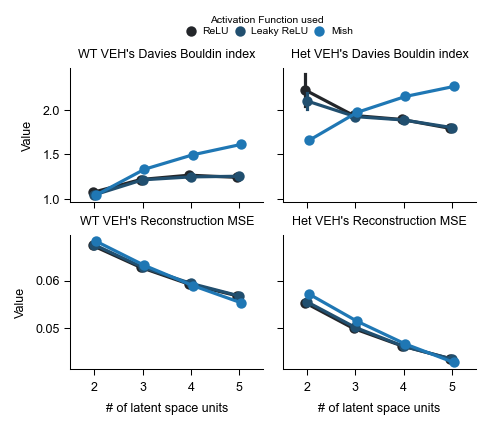

In [4]:
# Faceted pointplot: one panel per genotype
# fig,ax = plt.subplots(figsize=(8,6))
melt_sweep_df = sweep_results_df.melt(id_vars=['geno', 'activation', 'hidden_size'], 
                                        value_vars=['db_index', 'final_loss'], 
                                        var_name='metric', value_name='value')
melt_sweep_df['metric'] = melt_sweep_df['metric'].map({'db_index': 'Davies Bouldin index', 'final_loss': 'Reconstruction MSE'})
g = sns.FacetGrid(melt_sweep_df, col='geno',row = 'metric', height=1.5, aspect=1.1, sharey='row')
g.map_dataframe(sns.pointplot, x='hidden_size', y='value', hue='activation', dodge=True, errorbar='se')
g.set_titles("{col_name}'s {row_name}")
g.set_axis_labels("# of latent space units", "Value")
# Make room at top for suptitle AND legend
g.figure.subplots_adjust(top=0.8)
handles, labels = g.axes.flat[0].get_legend_handles_labels()
label_rename = {'relu': 'ReLU', 'leaky_relu': 'Leaky ReLU', 'mish': 'Mish'}
new_labels = [label_rename.get(label, label) for label in labels]
# Add legend at top center, between suptitle and plots
g.figure.legend(handles, new_labels, loc='upper center', bbox_to_anchor=(0.55, 0.93),ncol=len(new_labels),title="Activation Function used", frameon=False)
g.figure.suptitle(f"Reconstruction loss & DB index in Autoencoder Parameter Sweep:\n  {comparison.replace("_", " ")} activity | Ensemble: {ensemble.replace("_", " ")}",
                  y = 0.99, 
                  fontsize=7)
plt.savefig(f"sweep_results_{comparison}_{ensemble}.png", dpi=150, bbox_inches='tight')